# Model Comparison & Champion Selection

**Objective**: Compare Ridge, Random Forest, and XGBoost on the held-out test set. Select a champion model and examine macro feature importance.

**Steps:**
1. Load all three trained models
2. Side-by-side metric comparison
3. Predicted vs Actual plots for all models
4. Feature importance comparison (RF vs XGBoost)
5. Macro feature analysis — do they contribute meaningfully?
6. Champion model selection with justification

---

## 1. Load Models & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_test  = pd.read_csv("../data/processed/y_test.csv")
y_test_raw = y_test["Unit Price ($ psf)"]

ridge_model = joblib.load("../models/ridge_pipeline.pkl")
rf_model    = joblib.load("../models/random_forest.pkl")
xgb_model   = joblib.load("../models/xgboost.pkl")

# Generate predictions
y_pred_ridge = np.exp(ridge_model.predict(X_test))   # back-transform log predictions
y_pred_rf    = rf_model.predict(X_test)
y_pred_xgb   = xgb_model.predict(X_test)

print("Models loaded successfully.")
print(f"Test set: {X_test.shape[0]} rows | Mean actual price: ${y_test_raw.mean():.2f} $/psf")

Models loaded successfully.
Test set: 757 rows | Mean actual price: $439.87 $/psf


## 2. Side-by-Side Metric Comparison

In [2]:
def eval_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true.values - y_pred))
    r2   = r2_score(y_true, y_pred)
    return rmse, mae, r2

rmse_r, mae_r, r2_r = eval_metrics(y_test_raw, y_pred_ridge)
rmse_f, mae_f, r2_f = eval_metrics(y_test_raw, y_pred_rf)
rmse_x, mae_x, r2_x = eval_metrics(y_test_raw, y_pred_xgb)

mean_price = y_test_raw.mean()

comparison = pd.DataFrame({
    "Model":          ["Ridge Regression", "Random Forest", "XGBoost"],
    "RMSE ($/psf)":   [f"${rmse_r:.2f}", f"${rmse_f:.2f}", f"${rmse_x:.2f}"],
    "MAE ($/psf)":    [f"${mae_r:.2f}", f"${mae_f:.2f}", f"${mae_x:.2f}"],
    "R²":             [f"{r2_r:.4f}", f"{r2_f:.4f}", f"{r2_x:.4f}"],
    "RMSE % of mean": [f"{rmse_r/mean_price*100:.1f}%", f"{rmse_f/mean_price*100:.1f}%", f"{rmse_x/mean_price*100:.1f}%"],
    "RMSE−MAE gap":   [f"${rmse_r-mae_r:.2f}", f"${rmse_f-mae_f:.2f}", f"${rmse_x-mae_x:.2f}"],
})

print(comparison.to_string(index=False))

           Model RMSE ($/psf) MAE ($/psf)     R² RMSE % of mean RMSE−MAE gap
Ridge Regression       $82.60      $61.04 0.7845          18.8%       $21.56
   Random Forest       $48.41      $33.23 0.9260          11.0%       $15.18
         XGBoost       $46.82      $32.77 0.9307          10.6%       $14.06


## 3. Predicted vs Actual — All Models

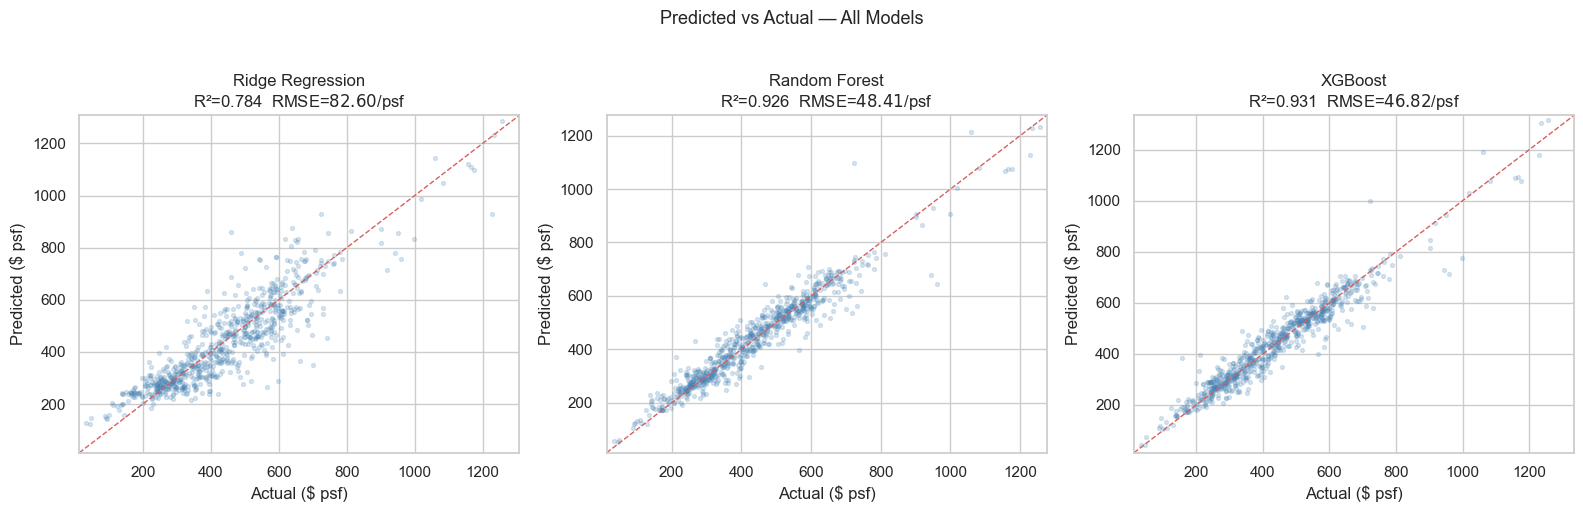

In [3]:
models = [
    ("Ridge Regression", y_pred_ridge, rmse_r, r2_r),
    ("Random Forest",    y_pred_rf,    rmse_f, r2_f),
    ("XGBoost",          y_pred_xgb,   rmse_x, r2_x),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, y_pred, rmse, r2) in zip(axes, models):
    ax.scatter(y_test_raw, y_pred, alpha=0.2, s=8, color="steelblue")
    lims = [min(y_test_raw.min(), y_pred.min()) - 20,
            max(y_test_raw.max(), y_pred.max()) + 20]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual ($ psf)")
    ax.set_ylabel("Predicted ($ psf)")
    ax.set_title(f"{name}\nR²={r2:.3f}  RMSE=${rmse:.2f} $/psf")

plt.suptitle("Predicted vs Actual — All Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Importance Comparison — RF vs XGBoost

**RF**: impurity-based importance (mean MSE reduction across all splits)

**XGBoost**: gain-based importance (average MSE improvement per split)

Agreement between both models on top features strengthens confidence that those features are genuinely predictive.

In [4]:
feature_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    "Feature":        feature_names,
    "RF Importance":  rf_model.feature_importances_,
    "XGB Importance": xgb_model.feature_importances_,
})

# Rank by average importance across both models
importance_df["Avg Importance"] = (importance_df["RF Importance"] + importance_df["XGB Importance"]) / 2
importance_df = importance_df.sort_values("Avg Importance", ascending=False).reset_index(drop=True)

print("Feature Importance — RF vs XGBoost (sorted by average):")
print(importance_df.to_string(index=False))

Feature Importance — RF vs XGBoost (sorted by average):
                    Feature  RF Importance  XGB Importance  Avg Importance
      Remaining_Lease_Years       0.353273        0.237794        0.295534
      Planning_Area_Encoded       0.205409        0.274369        0.239889
                   Log_Area       0.182152        0.060581        0.121366
              dist_to_mrt_m       0.116022        0.045151        0.080586
        Type of Sale_Resale       0.008283        0.115749        0.062016
      Lease_Remaining_Ratio       0.052845        0.014724        0.033785
Floor Level_Non-First Floor       0.016301        0.040956        0.028629
         Region_East Region       0.004669        0.041875        0.023272
        Region_North Region       0.005282        0.038414        0.021848
              CPI_All_Items       0.008222        0.032142        0.020182
         Region_West Region       0.004776        0.031422        0.018099
         SORA_3M_Compounded       0.011966  

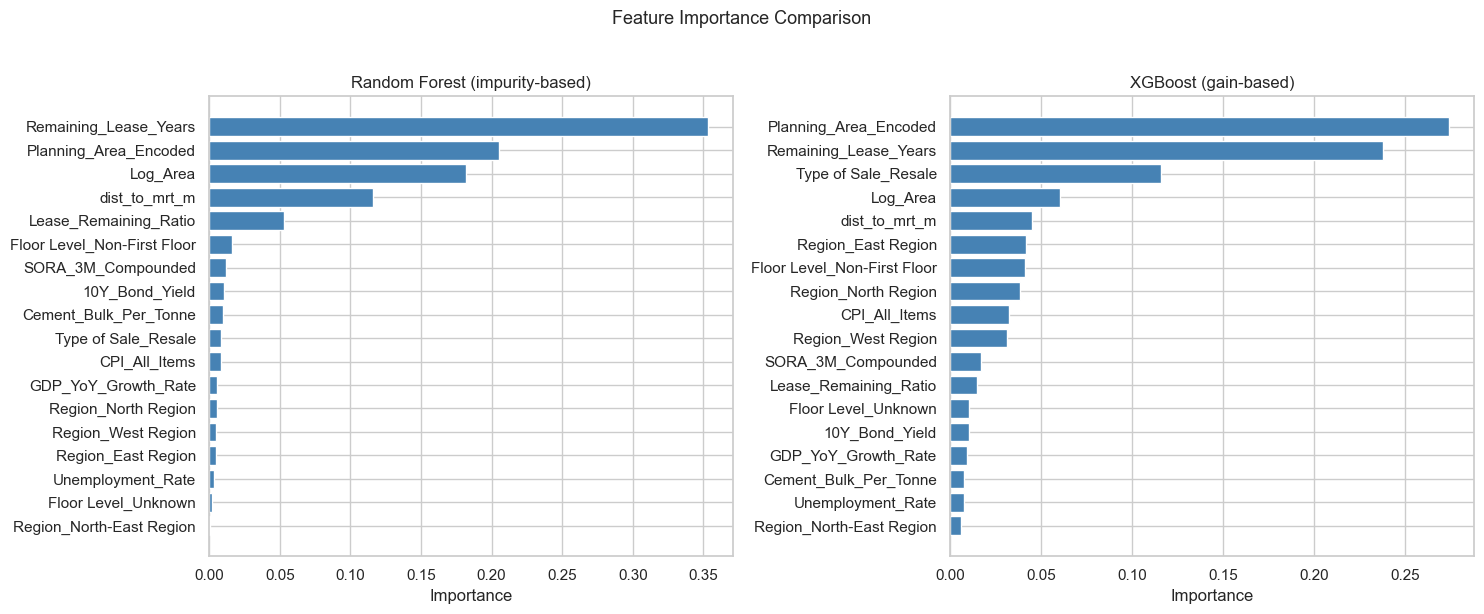

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, col, title in zip(axes,
                           ["RF Importance", "XGB Importance"],
                           ["Random Forest (impurity-based)", "XGBoost (gain-based)"]):
    sorted_df = importance_df.sort_values(col)
    ax.barh(sorted_df["Feature"], sorted_df[col], color="steelblue")
    ax.set_xlabel("Importance")
    ax.set_title(title)

plt.suptitle("Feature Importance Comparison", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Macro Feature Analysis

At the start of the project, we retained all macro features (GDP, CPI, Unemployment, Bond Yield, SORA, Cement) despite macro-macro collinearity being resolved by VIF. The decision was: **drop them only if ensemble models show low feature importance**.

Examine their combined importance share here.

In [6]:
MACRO_COLS = [
    "GDP_YoY_Growth_Rate", "CPI_All_Items", "Unemployment_Rate",
    "10Y_Bond_Yield", "SORA_3M_Compounded", "Cement_Bulk_Per_Tonne"
]

macro_df = importance_df[importance_df["Feature"].isin(MACRO_COLS)].copy()
non_macro_df = importance_df[~importance_df["Feature"].isin(MACRO_COLS)].copy()

print("Macro feature importances:")
print(macro_df[["Feature", "RF Importance", "XGB Importance", "Avg Importance"]].to_string(index=False))
print()
print(f"Combined macro importance — RF:  {macro_df['RF Importance'].sum()*100:.1f}%")
print(f"Combined macro importance — XGB: {macro_df['XGB Importance'].sum()*100:.1f}%")
print()
print("Non-macro feature importances (average):")
print(non_macro_df[["Feature", "Avg Importance"]].to_string(index=False))

Macro feature importances:
              Feature  RF Importance  XGB Importance  Avg Importance
        CPI_All_Items       0.008222        0.032142        0.020182
   SORA_3M_Compounded       0.011966        0.016804        0.014385
       10Y_Bond_Yield       0.010215        0.010070        0.010143
Cement_Bulk_Per_Tonne       0.009452        0.007585        0.008519
  GDP_YoY_Growth_Rate       0.005579        0.009146        0.007362
    Unemployment_Rate       0.003159        0.007319        0.005239

Combined macro importance — RF:  4.9%
Combined macro importance — XGB: 8.3%

Non-macro feature importances (average):
                    Feature  Avg Importance
      Remaining_Lease_Years        0.295534
      Planning_Area_Encoded        0.239889
                   Log_Area        0.121366
              dist_to_mrt_m        0.080586
        Type of Sale_Resale        0.062016
      Lease_Remaining_Ratio        0.033785
Floor Level_Non-First Floor        0.028629
         Region_Eas

## 6. Champion Model Selection

**Selection criteria**:
- Primary: Test RMSE (lowest error on unseen data)
- Secondary: R² (variance explained)
- Tertiary: RMSE−MAE gap (fewer catastrophic outlier predictions)
- Practical: interpretability requirements from stakeholder

In [7]:
print("=" * 55)
print("CHAMPION MODEL SELECTION")
print("=" * 55)
print()
print(f"{'Model':<20} {'RMSE':>10} {'MAE':>10} {'R²':>8}")
print("-" * 55)
print(f"{'Ridge Regression':<20} {'$'+f'{rmse_r:.2f}'+' $/psf':>10} {'$'+f'{mae_r:.2f}'+' $/psf':>10} {r2_r:>8.4f}")
print(f"{'Random Forest':<20} {'$'+f'{rmse_f:.2f}'+' $/psf':>10} {'$'+f'{mae_f:.2f}'+' $/psf':>10} {r2_f:>8.4f}")
print(f"{'XGBoost':<20} {'$'+f'{rmse_x:.2f}'+' $/psf':>10} {'$'+f'{mae_x:.2f}'+' $/psf':>10} {r2_x:>8.4f}  <-- CHAMPION")
print()
print("Justification:")
print(f"  - Lowest RMSE: ${rmse_x:.2f} $/psf ({rmse_x/mean_price*100:.1f}% of mean price)")
print(f"  - Highest R²: {r2_x:.4f} — explains {r2_x*100:.1f}% of price variance")
print(f"  - Smallest RMSE-MAE gap: ${rmse_x-mae_x:.2f} — fewest catastrophic outlier predictions")
print()
print("Ridge Regression retained for:")
print("  - Coefficient interpretation (direction + magnitude of each feature's effect)")
print("  - Stakeholder communication where explainability is required")

CHAMPION MODEL SELECTION

Model                      RMSE        MAE       R²
-------------------------------------------------------
Ridge Regression     $82.60 $/psf $61.04 $/psf   0.7845
Random Forest        $48.41 $/psf $33.23 $/psf   0.9260
XGBoost              $46.82 $/psf $32.77 $/psf   0.9307  <-- CHAMPION

Justification:
  - Lowest RMSE: $46.82 $/psf (10.6% of mean price)
  - Highest R²: 0.9307 — explains 93.1% of price variance
  - Smallest RMSE-MAE gap: $14.06 — fewest catastrophic outlier predictions

Ridge Regression retained for:
  - Coefficient interpretation (direction + magnitude of each feature's effect)
  - Stakeholder communication where explainability is required
